In [2]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

df = pd.read_csv(url)

# Phase 1 : Data Inspection

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [51]:
pd.DataFrame({
    "Columns" : df.columns,
    "Dtypes" : df.dtypes
})

,Columns,Dtypes
gender,gender,str
SeniorCitizen,SeniorCitizen,int64
Partner,Partner,str
Dependents,Dependents,str
tenure,tenure,int64
PhoneService,PhoneService,str
MultipleLines,MultipleLines,str
InternetService,InternetService,str
OnlineSecurity,OnlineSecurity,str
OnlineBackup,OnlineBackup,str


In [52]:
df['TotalCharges'].dtype
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [53]:
cat_cols = df.select_dtypes(include=["str"]).columns.tolist() + ["SeniorCitizen"] 
cat_cols.remove("Churn")
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [54]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("SeniorCitizen")
num_cols 

['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df.drop(columns=["customerID"] , inplace=True)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [59]:
pd.DataFrame(df["Churn"].value_counts(normalize=True)).reset_index()

,Churn,proportion
0,No,0.73463
1,Yes,0.26537


In [81]:
null_count = df[cat_cols + num_cols].isnull().sum()
null_count = null_count[null_count>0]

print(f"Total Null Count in whole Dataset : {null_count}")



Total Null Count in whole Dataset : TotalCharges    11
dtype: int64


# Phase 2 : Target Variable Analysis

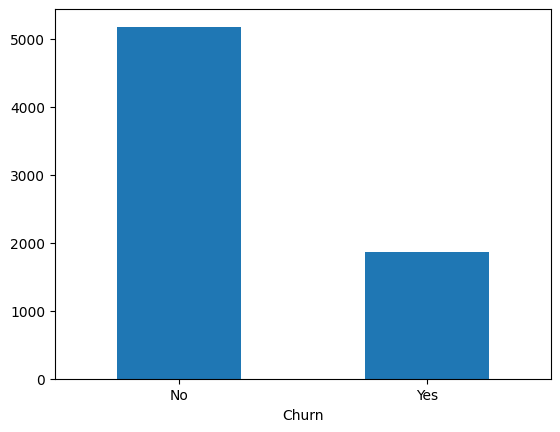

In [ ]:
df["Churn"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

### Class Imblance

In [94]:
imblance_ratio = df["Churn"].value_counts()["No"] / df["Churn"].value_counts()['Yes']
print(f"Class Imblance Ration No/Yes : {imblance_ratio:.3f}")

Class Imblance Ration No/Yes : 2.768


In [104]:
baseline_accuracy = df['Churn'].value_counts(normalize=True).max()
(baseline_accuracy.round(3)) * 100

np.float64(73.5)

# Phase 3 : Numerical Features EDA + Statistical Inference

### Numerical features with target Variable ( Churn(No) v/s Churn(Yes) )

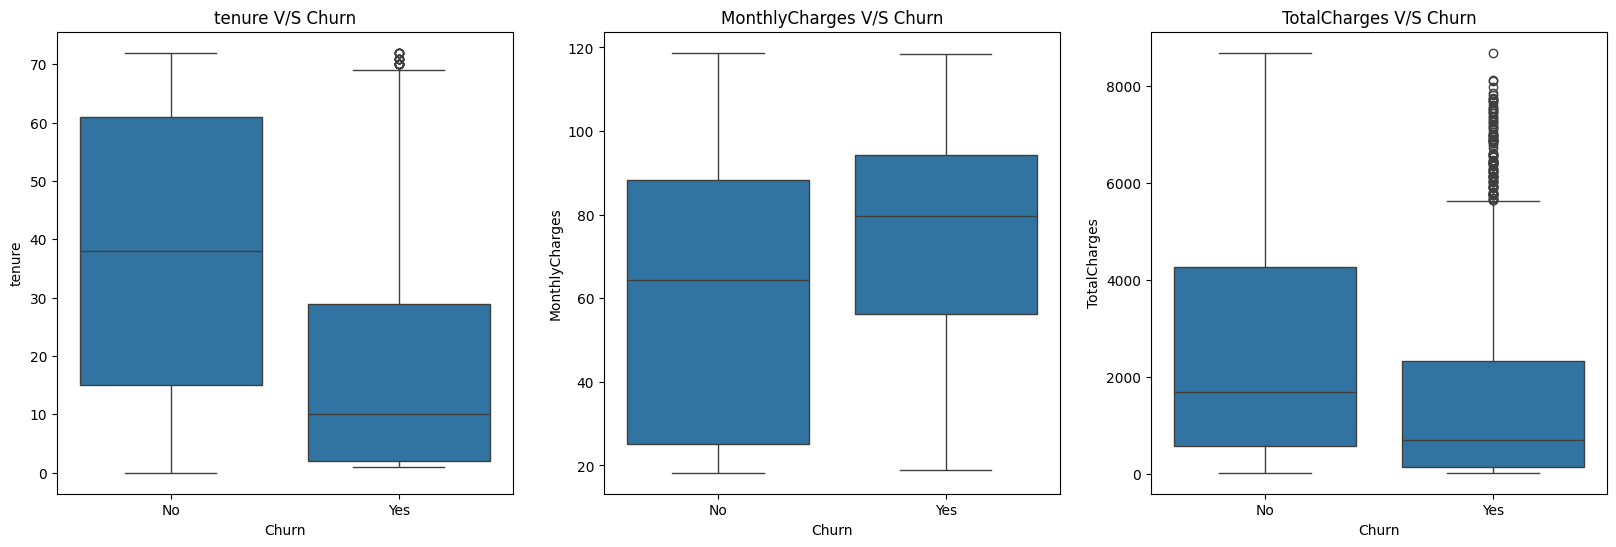

In [118]:
fig , ax = plt.subplots(1 , 3 , figsize=(20 , 6))

ax = ax.flatten()

for i,col in enumerate(num_cols):

    sns.boxplot(
        data = df ,
        x = "Churn",
        y = col,
        ax = ax[i]
    )

    ax[i].set_title(f"{col} V/S Churn")

### T-Test

In [ ]:
from scipy.stats import ttest_ind

T_Test = []

for col in num_cols:
    churned = df[ df["Churn"]=="Yes" ][col].dropna()
    not_churned = df[ df["Churn"]=="No" ][col].dropna()
    t_stat , p_value = ttest_ind(churned , not_churned)
    
    T_Test.append({
        "Column" : col,
        "t_stat" : t_stat,
        "p_value" : p_value
    })

pd.DataFrame(T_Test).sort_values("p_value")

,Column,t_stat,p_value
0,tenure,-31.579551,7.999058e-205
2,TotalCharges,-17.068827,4.876866e-64
1,MonthlyCharges,16.536738,2.706646e-60
